<h1 style="color: green;">What drives the price of a car?</h1>

---


### Assignment Overview:

In this assignment, we are instructed to explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Our goal is to understand what factors make a car more or less expensive.  As a result of our analysis, we should provide clear recommendations to our client -- a used car dealership -- as to what consumers value in a used car. 

We are instructed to use the [CRISP-DM](https://en.wikipedia.org/wiki/Cross-industry_standard_process_for_data_mining) framework for the project.

 <h2 style="color: green;">01. Business Understanding:</h2>
 
 ---

The used car market is characterized by high volatility and complex pricing structures driven by a multitude of variables. For a dealership to remain competitive and profitable, it must move beyond "gut-feel" pricing and adopt a data-driven valuation strategy. The core challenge here is to identify and quantify the specific vehicle attributes (e.g. amke & model, odometer, age, fuel type, condition, etc.) that have the most significant impact on a vehicle's market value. By analyzing a dataset of 426,000 vehicles, this project aims to provide the client with a predictive framework that clarifies why certain cars command a premium and others do not.

It is worth noting that optimizing for dealer profit margin is outside of the scope of this model; we'll only be optimizing for sale price prediction (which represents value to the consumer). Value to the dealer would need to also consider acquisition cost, as this will determine their profit. Said another way, the cars that are priced the highest may not necessarily be the most profitable. Given this, we assume that our client (a used car dealership) has their own formula for calculating their expected profit when equipped with the acuisition cost (which they will obtain) and the predicted sale price (which our model will provide).

 <h2 style="color: green;">02. Data Understanding:</h2>

---

### Methodology:
For the Data Understanding phase of CRISP-DM, we'll use the dataset of 426k used cars and examine the metadata to better understand the form and content that is present. 
One of the most important early conclusions we'll need to draw is to verify that there is a well-populated feature for vehicle price, which will be the target feature of our model, as aligned with the Buiness Understanding. We'll also need to closely examine other features to understand what information they contain. 

#### [Data Structure & Sparse Rows]:
We'll look closely at the variance in non-null values across features, and decide how to handle null data case-by-case. In some cases it may be appropriate to drop the rows; in other cases it may be better to use [imputation](https://en.wikipedia.org/wiki/Imputation_(statistics)).

#### [Feature Data Types]:
We'll also look closely at the `dtype` of our features:

- **Numeric Features:** We'll examine their statistical properties (e.g. mean, median, standard deviation). 
- **Non-Numeric Fetaures:** We'll need to see which are categorical and determine an approach (generally, One-Hot Encoding for features with low cardiality, and Target Encoding for features with high cardinality. We will carefully manage the data to reduce risk of target leakage).


#### [Data Filtering Criteria]:
We'll identify data filtering criteria such as:

- **Outliers:** We'll look at variance in feature values and use statistical tools such as IQR to evaluate the data for outliers.
- **Redundant Features:** We'll need to think critically about whether there are redundant features in the data, so that we do not fall into the [Curse of Dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality).
- **Unneeded Features:** We'll see if any features are unneeded based on our output goals.

#### [Visual Examination]:
After undertaking some exploration of the data structure, properties and values, we'll also generate some plots of the data, for a visual examination. Additional properties or 
relationships in the data may become more apparent with a visual examination.

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import HuberRegressor, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler, TargetEncoder


In [106]:
def print_value_counts(s, limit=1000):
    i = 0
    for value, count in s.items():
        if (i >= limit):
            break
        print(f"{value}: {count}")
        i += 1
    

In [107]:
car_data = pd.read_csv('data/vehicles.csv')
car_data.sample(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
342235,7314336183,rhode island,4900,2008.0,nissan,murano,excellent,6 cylinders,gas,156000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ri
13003,7313152579,prescott,34588,2019.0,ram,1500,like new,8 cylinders,gas,26979.0,clean,automatic,1C6RR6TT9KS661191,rwd,full-size,truck,grey,az
21415,7315374220,bakersfield,6975,2009.0,toyota,camry,excellent,4 cylinders,gas,161000.0,clean,automatic,NaN,fwd,mid-size,sedan,silver,ca
191002,7307594240,western massachusetts,0,2016.0,gmc,savana commercial cutaway,excellent,8 cylinders,gas,70917.0,clean,automatic,1GD37RCG2G1268960,rwd,NaN,NaN,NaN,ma
86036,7316861346,new haven,0,2017.0,fiat,124 spider,excellent,4 cylinders,gas,40236.0,clean,automatic,JC1NFAEK9H0101969,rwd,compact,convertible,white,ct


In [108]:
car_data.info()
car_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [109]:
Q1 = car_data['price'].quantile(0.25)
Q3 = car_data['price'].quantile(0.75)
IQR = Q3 - Q1
multiple = 1.5

price_lower_bound = Q1 - (multiple * IQR)
price_upper_bound = Q3 + (multiple * IQR)


### 02. Data Understanding - Initial Findings Based on Data Attributes:

Initial examination of the data reveals some useful information as we think ahead to the Data Preparation phase:

1. There is a `price` feature which will serve as the target for the business problem we've defined, and it is fully populated.

1. The target feature -- `price` -- has good variation within 25 - 75% quartiles. There is an order-of-magnitude difference between 25% and 75% values ($5900.00 vs. $26,485.75), with an [IQR](https://en.wikipedia.org/wiki/Interquartile_range) of $20,585.75.

1. The price feature also has wide outliers, based on eyeballing the min ($0) and max ($3.7 billion) values as well as noting that the mean is higher than the 75% value (mean is skewed by outliers). The standard deviation is also several orders of magnitude higher than the IQR. 
    - The max value for price is clearly an error -- no used car costs $3.7 billion -- and the min value of $0 also doesn't make sense for this purpose. We will need to filter.
    - However using `IQR * 1.5` in fence calculations probably isn't the best approach here -- since Q1 value is so low, the lower bound will be negative ($0 values will be kept); and the upper bounds will only be set to $57,364.38, which could exclude some luxury cars, which will create unintended bias in the model.
    - We'll start with a manual filter on price (>$500 and <$500k) before plotting, and finalize this approach during the Data Preparation phase.

1. There is also high variance in non-null values across attributes. The attribute with the lowest number of on-nulls is `size`, contains values such as 'compact'. A prelinminary assupmtion is that there could be some relationship between this categorical attribute and the final price, however since this value exists for only ~1/4 of the rows, it is not a good candidate for imputation and should be discarded. Fortunately there is another categorical attribute -- `type` -- which includes values such as 'truck', 'coupe', and 'sdean', which has values for ~3/4 of the rows, so this could be a suitable attribute to for signal related to the size of the vehicle (e.g. trucks will be larger than coupes).

1. ID and VIN are unneeded and can be discarded.

1. The `year` and `region` features also have a lot of variance.
    - `year` min value is 1900. For our model we can assume that cars > 40 years old could be considered "classic" and therefore out of the range that used car dealerships would target (unless they specialize in classic cars). We can filter on year and refine further during Data Preparation if needed.
    - An examination of `region` unique values reveals that they are inconsistent (e.g. cities, metros, and araes of states are all included) and very broad (400+ unique values). We can discard this data. A regional attirbution may be useful for identifying pricing trneds, assuming it could be more streamlined. We'll explore whether a more meaningful regional association can be constructed from the `state` values during the Data Preparation phase.

1. The `odometer` feature is also somewhat noisy -- the max value is 10m miles, which seems unrealistic. We can safely assume that used car dealers likely wouldn't want to purchase a used car with > 300k miles (that is arguably too high, but seems like a reasonable set of values to include for predictive purposes).

Next we will examine the data visually using Seaborn plots.

In [110]:
drop_columns = ['id', 'VIN', 'size', 'region']
dropna_subset = ['year']

# Ignore IQR and use custom values.
price_lower_bound = 500
price_upper_bound = 500000
minimum_year = 1986
maximum_odometer = 300000.0

car_data_pre_filtered = car_data.drop(columns=drop_columns).\
    dropna(subset=dropna_subset).\
    query('price >= @price_lower_bound and price <= @price_upper_bound ' \
          'and year >= @minimum_year and odometer <= @maximum_odometer').\
    sort_values(by='price')

car_data_pre_filtered['year'] = car_data_pre_filtered['year'].astype('int64')


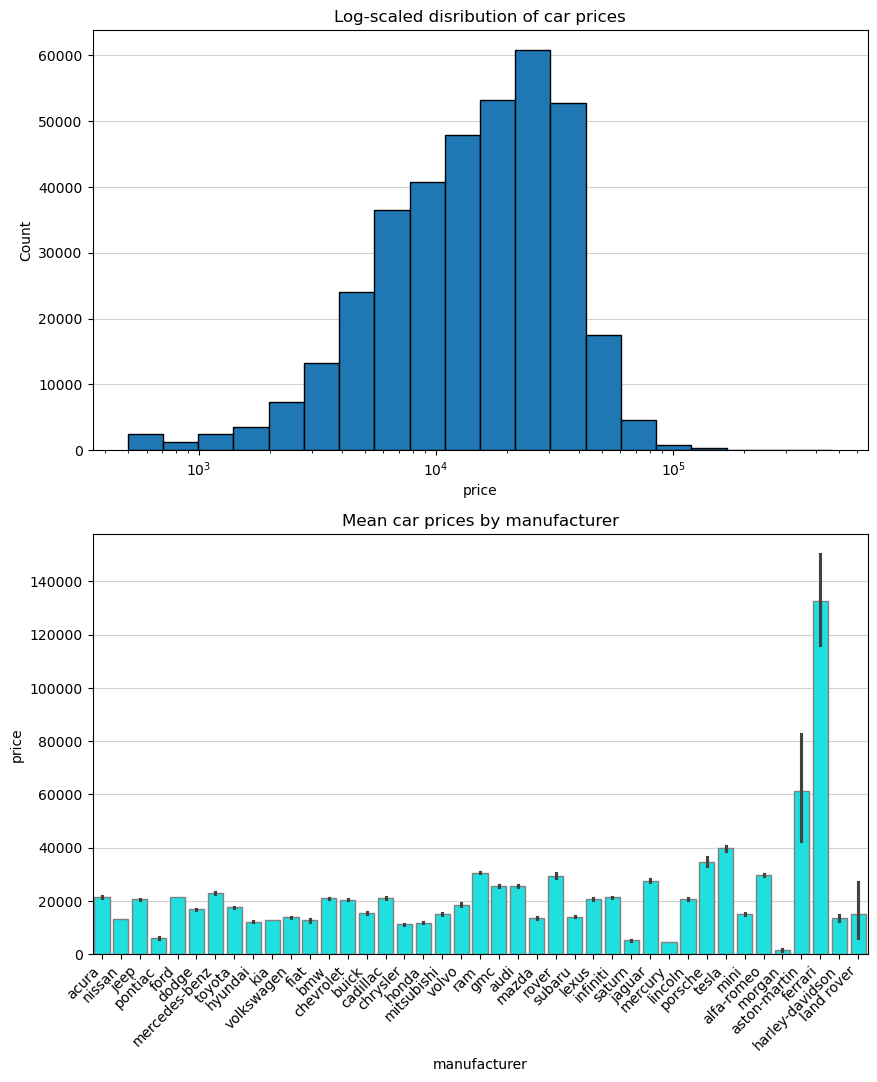

In [111]:
# Utility function
def draw_grid(axes):
    for ax in axes:
        ax.set_axisbelow(True)
        ax.grid(True, axis='y', linestyle='-', color='lightgray')

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
draw_grid(axes)

axes[0] = sns.histplot(data=car_data_pre_filtered['price'], bins = 20,
    log_scale=True, ax=axes[0], edgecolor='black', alpha=1)
# Draw grid below the bars.
axes[0].set_title('Log-scaled disribution of car prices')

sns.barplot(data=car_data_pre_filtered, x='manufacturer', y='price', ax=axes[1],
    color='cyan', edgecolor='gray')
axes[1].set_title('Mean car prices by manufacturer')

plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

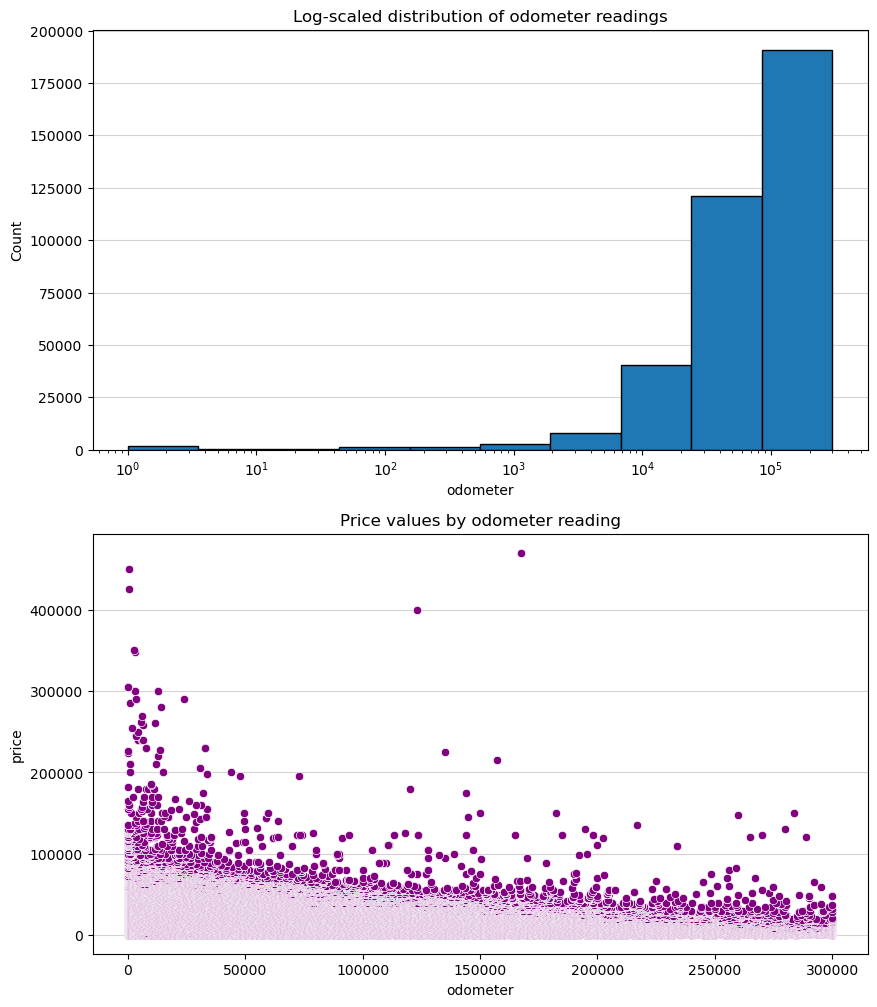

In [112]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
draw_grid(axes)

sns.histplot(data=car_data_pre_filtered['odometer'], log_scale=True,
    bins = 10, ax=axes[0], edgecolor='black', alpha=1)
axes[0].set_title('Log-scaled distribution of odometer readings')

sns.scatterplot(data=car_data_pre_filtered[['odometer','price']], x='odometer', 
    y='price', ax=axes[1], color='purple')
axes[1].set_title('Price values by odometer reading')

plt.show()




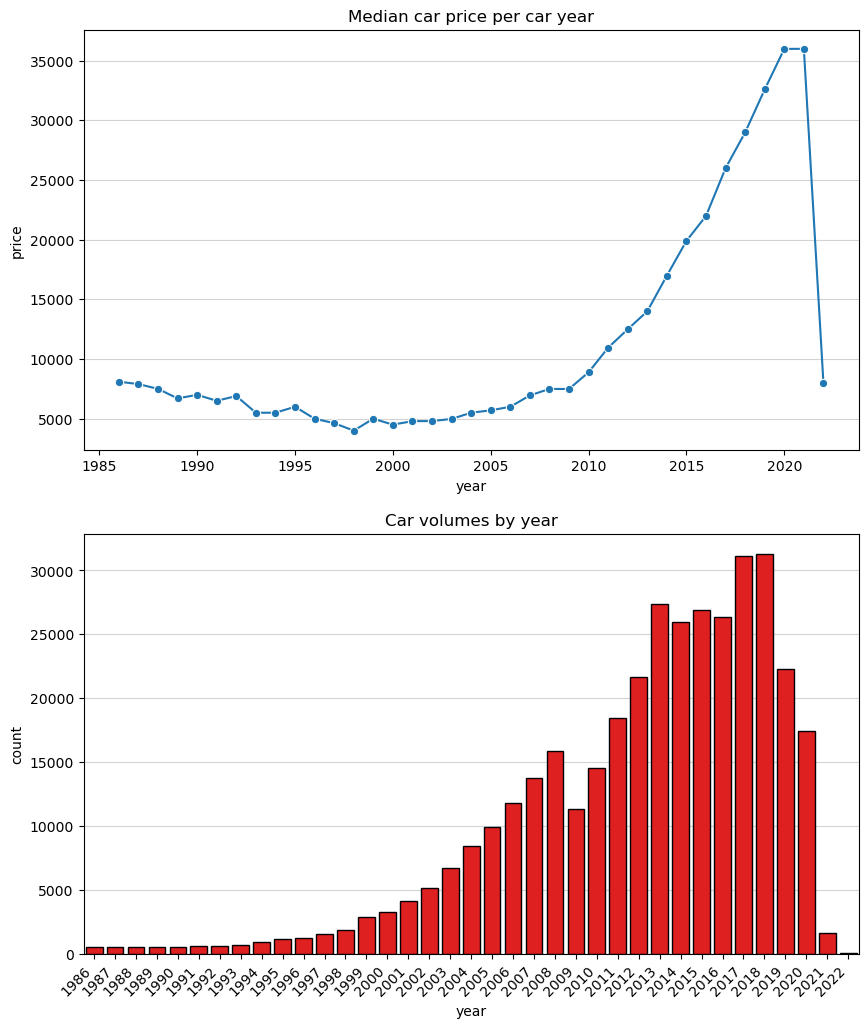

In [113]:
median_prices_per_year = car_data_pre_filtered.groupby('year')[['price']].median()

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
draw_grid(axes)

sns.lineplot(data=median_prices_per_year, x='year', y='price', marker='o',
    ax=axes[0])
axes[0].set_title('Median car price per car year')

#car_counts_by_year = car_data_pre_filtered.groupby('year').count()
sns.countplot(data=car_data_pre_filtered, x='year', ax=axes[1], color='red',
    edgecolor='black')
axes[1].set_title('Car volumes by year')

plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

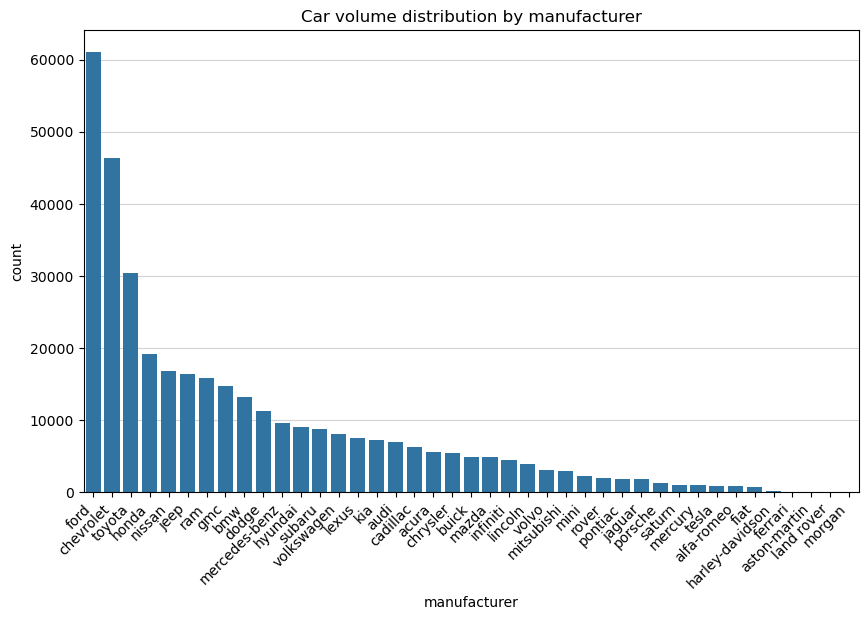

In [114]:
manufacturer_counts = car_data_pre_filtered['manufacturer'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
draw_grid([ax])

sns.barplot(data=manufacturer_counts)
ax.set_title('Car volume distribution by manufacturer')

plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

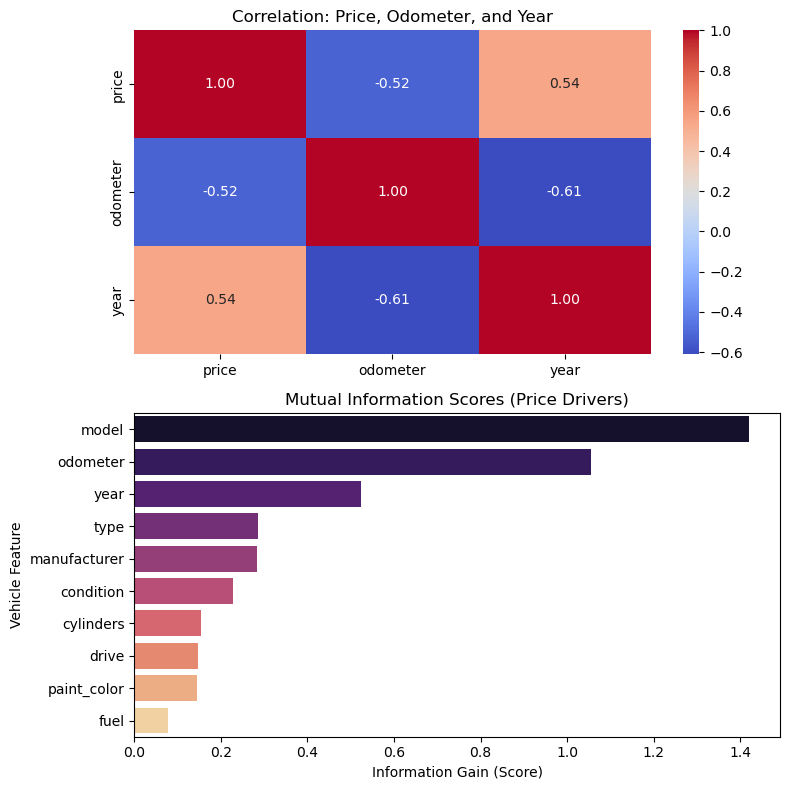

In [115]:
# Look for correlations using traditional correlation matrix and MI
corr_matrix = car_data_pre_filtered[['price', 'odometer', 'year']].corr()

# Representative sample for speeding up MI. Must remove NaN's.
mi_sample_df = car_data_pre_filtered.sample(100000, random_state=42).copy()
category_cols = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 
    'drive', 'type', 'paint_color']
mi_sample_df = mi_sample_df.dropna(
    subset=category_cols + ['year', 'odometer', 'price'])

X_mi = mi_sample_df[category_cols + ['year', 'odometer']]
y_mi = mi_sample_df['price']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_mi_encoded = X_mi.copy()
X_mi_encoded[category_cols] = encoder.fit_transform(X_mi[category_cols])

# discrete_features needs column indices for categories
mi_scores = mutual_info_regression(X_mi_encoded, y_mi, 
    discrete_features=[0,1,2,3,4,5,6], random_state=42)

mi_results = pd.Series(mi_scores, index=X_mi.columns).\
    sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(8,8))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
    ax=axes[0])
axes[0].set_title("Correlation: Price, Odometer, and Year")

sns.barplot(x=mi_results.values, y=mi_results.index, palette='magma',
    hue=mi_results.index, ax=axes[1])
axes[1].set_title("Mutual Information Scores (Price Drivers)")
axes[1].set_xlabel("Information Gain (Score)")
axes[1].set_ylabel("Vehicle Feature")

plt.tight_layout()
plt.show()





In [116]:
# Check out what's going on with model MI in more detail.
model_check = car_data_pre_filtered.copy()
model_check['model'] = model_check['model'].fillna('unknown')
# clean up dirty data.
model_check = model_check[~model_check['model'].str.contains('\\$', regex=True)]

counts = model_check['model'].value_counts()

# Create an easier to read frequency distribution table.
counts_df = counts.reset_index()
counts_df.columns = ['model', 'count']

print(len(counts))
print(len(counts[counts > 1]))

#plt.figure(figsize=(10, 100))
#sns.barplot(data=counts_df.head(500), x='count', y='model')
#plt.title("Top 500 Vehicle Models")
#plt.show()

24666
12404


### 02. Data Understanding - Conclusions:

The visual plots were helpful; they provided some additional insights about the data:

- Moderate positive correlation between `year` & `price` (newer cars are generally priced higher).
- Moderate negative correlation between `odometer` & `price` (lower mileage cars are generally priced higher). This is also reflected on the scatterplot.
- Some luxury brands (Ferrari, Aston-Martin) have high mean prices but the confidence interval for this signal is low -- volume for these brands is also very low relative to other manufacturers.
- The log-scaled distribution of `price` and `odometer` makes the variance easier to visualize.
- Pre-1996 volume is fairly low, and there is a dip in price between 1986 to 1996. This could indicate different things (e.g. perhaps 40 year old cars are starting to fall into the "classic" category). Since volume is low, we'll trim to a 30 year range for modelling.
- Year 2022 is relatively sparse, and prices drop sharply that year (likely not enough diversity in the volume), so we'll trim that year as well.
- The MI scores revealed strong information gain related to `model`, which is enticing. However looking more closely at the value counts and values for this feature it is clear that it's quite noisy -- model names include lots of variations, e.g. '1500' vs. 'silverado 1500' vs. '1500 crew cab big horn' are all variations of the same vehicle. Doing some analysis on the counts revels that there are 24666 unique values; 5577 of those have > 5 entries; 7749 > 3; 12404 > 1. So although it is a dirty long-tail distribution, there are still > 5k with > 5 entries, and the MI score is high, indicating this is a strong predictor. I'll attempt to clean the data (e.g. mapping long-tail categories to 'Other') in Data Preparation, rather than discard it outright. I'll have to be mindful of overfitting risk.
- The MI scores also confirmed that there is some information gain for features like `cylinders`, `drive`, `paint_color` as relates to `price` -- these pertain to vehicle trim options which are sometimes also part of the `model` name. There may be some redundancy in these features, and I am wary of the [Curse of Dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality); I'll make a final determination on whether to include them during Modelling.



 <h2 style="color: green;">03. Data Preparation:</h2>

---

### Methodology:

1. Remove some of the features as driven by insights from 02. Data Understanding. 
1. Data cleanup & enrichment
1. Imputation
1. Encoding
1. Feature Engineering (PolynomialFeatures)

In [117]:
cleaned_df = car_data.copy()

car_drop_columns = ['id', 'VIN', 'size', 'region']
price_lower_bound = 500
price_upper_bound = 500000
minimum_year = 1996
maximum_year = 2021
maximum_odometer = 300000.0


# Filter by bounds 
cleaned_df = cleaned_df.drop(columns=car_drop_columns).\
    query('price >= @price_lower_bound and price <= @price_upper_bound ' \
            'and year >= @minimum_year and year <= @maximum_year and '\
            'odometer <= @maximum_odometer').\
    sort_values(by='price')

# Add Region
states_df = pd.read_csv('data/states_to_regions.csv')
states_df.drop(columns=['State', 'Division'], inplace=True)
states_df = states_df.rename(columns={'State Code': 'state', 'Region': 'region'})

cleaned_df['state'] = cleaned_df['state'].str.upper()
cleaned_df = pd.merge(cleaned_df, states_df, on='state', how='left')



In [118]:
def cleanup_strings(df, columns):
    for column in columns:
        df[column] = df[column].str.replace(r'[^a-zA-Z0-9\-_.]', '', regex=True)
        df[column] = df[column].astype(str).str.lower().str.strip()
    return df

def clean_car_models(df, threshold=10):
    #Remove Manufacturer from the start of the Model name
    # e.g., "ford f-150" becomes "f-150"
    def remove_make(row):
        make = str(row['manufacturer'])
        model = str(row['model'])
        if model.startswith(make):
            return model[len(make):].strip()
        return model

    df['model'] = df.apply(remove_make, axis=1)

    # Extract just the first two words for more consistent names
    # e.g. "silverado 1500 crew cab" and "silverado 1500 lariat" -> 
    # "silverado 1500"
    df['model'] = df['model'].str.split().str[:2].str.join(' ')

    # Filter long tail
    model_counts = df['model'].value_counts()
    rare_models = model_counts[model_counts < threshold].index
    df.loc[df['model'].isin(rare_models), 'model'] = 'other_model'
    
    return df

cleaned_df = cleanup_strings(cleaned_df, cleaned_df.select_dtypes(exclude=['number']).columns)
cleaned_df = clean_car_models(cleaned_df, 5)


# Imputation


# Dtype cleanup to reduce memory footprint
category_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 
    'transmission', 'drive',  'type', 'paint_color', 'state', 'region']
for category in category_cols:
    cleaned_df[category] = cleaned_df[category].astype('category')
cleaned_df['year'] = cleaned_df['year'].astype('int64')

In [119]:
# Debug
print('info:\n')
print(cleaned_df.info())
print('--------------')

print('describe:\n')
print(cleaned_df.describe())
print('--------------')

print('sample(10): \n')
print(cleaned_df.sample(10))
print('--------------')

temp_counts = cleaned_df['model'].value_counts()

print(f"model feature -- total unique values: {len(temp_counts)}\n")
print('model feature - value + counts (top 20)\n')
print_value_counts(temp_counts, 20)
#print(temp_counts[:100])

# Quick check on title status and condition, which are categories which have 6 values each (reasonable spread for OHE)

# states -- make them all caps
# states -- join to get region
# model -- check for invalid / garbage data -- e.g. one value is something about an incentive program -- replace with unknown
# manufacturer -- replace NaN with unkonnw -- explain why on this + model


info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362827 entries, 0 to 362826
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   price         362827 non-null  int64   
 1   year          362827 non-null  int64   
 2   manufacturer  362827 non-null  category
 3   model         362827 non-null  object  
 4   condition     362827 non-null  category
 5   cylinders     362827 non-null  category
 6   fuel          362827 non-null  category
 7   odometer      362827 non-null  float64 
 8   title_status  362827 non-null  category
 9   transmission  362827 non-null  category
 10  drive         362827 non-null  category
 11  type          362827 non-null  category
 12  paint_color   362827 non-null  category
 13  state         362827 non-null  category
 14  region        362827 non-null  category
dtypes: category(11), float64(1), int64(2), object(1)
memory usage: 14.9+ MB
None
--------------
describe:

         

### Note:

Remember to list out tradeoffs of IQR, e.g. model will be constrained to 75% value.

_IncompleteInputError: incomplete input (1850369942.py, line 3)

# What drives the price of a car?

![](images/kurt.jpeg)

**ASSIGNMENT OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding Instructions:

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Data Understanding Instructions:

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Preparation Instructions:

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### Modeling Instructions:

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation Instructions:

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment Instructions:

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.